# Exploratory Data Analysis

**Project:** [Energy Effiency Analysis]

**Team:** [Matthan Call & Brandon Smith]

**Date:** [2/22/2026]

## Table of Contents
1. Setup & Load Data
2. Data Quality Check
3. Target Variable Analysis
4. Feature Distributions
5. Correlation Analysis
6. Key Findings Summary

### Data information  
Data comes from building heating and cooling simulations performed at the University of Oxford.

* __relative_compactness:__ 12 values  
  the ratio of a buildings surface area to its enclosed volume.
* __surface_area:__ 12 values  
  The total external surfaces of the building (exterior walls and roof).
* __wall_area:__ 7 values  
  The exterior wall surface area.
* __roof_area:__ 4 values  
  The roof surface area.
* __overall_height:__ 2 values  
  How tall the building is
* __orientation:__ 4 values  
  Categorical variables ranging from 2 to 5.  
  2 (North), 3 (East), 4 (South), 5 (West)
* __glazing_area:__ 4 values
  The window to wall ratio of a building, typically limited to 40%. Only 4 variables (0, 0.1, 0.25, 0.4), so likely estimated.
* __glazing_area_dist:__ 6 values  
  Categorical variables ranging from 0-5.
  0 is no glazing, 1 is uniform distribution (25% of glazing per wall)
  2 (North), 3 (East), 4 (South), 5 (West), with the primary wall featuring 55% of glazing, and the remaing walls 15%.
* __heating_load:__ The amount of energy (in 1000 BTUs) to be added to maintain a specific temperature.
* __cooling_load:__ The amount of energy (in 1000 BTUs) to be removed to maintain a specific temperature.



## 1. Setup & Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

#print("✓ Libraries loaded!")

In [2]:
# Load your data

df = pd.read_csv("../data/raw/ENB2012_data.csv")

df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [3]:
## providing descriptive names for predictor variables
df = df.rename(columns={'X1':'relative_compactness','X2':'surface_area',
    'X3':'wall_area','X4':'roof_area','X5':'overall_height','X6':'orientation',
    'X7':'glazing_area','X8':'glazing_area_dist','Y1':'heating_load','Y2':'cooling_load'})

### 1. Project Overview:
- What are you predicting? Heating and cooling load.
- Why does this problem matter? Efficiency of heating and cooling leads to less energy waste.
- Is this regression or classification? Regression.
- Where did you get your data?  https://archive.ics.uci.edu/dataset/242/energy+efficiency
- How many rows and columns? 768 rows, 10 columns.


## 2. Data Quality Check

**Questions to answer:**
- What are the data types? Floats and Integers
- Are there missing values? None.
- Are there duplicate rows? None.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   relative_compactness  768 non-null    float64
 1   surface_area          768 non-null    float64
 2   wall_area             768 non-null    float64
 3   roof_area             768 non-null    float64
 4   overall_height        768 non-null    float64
 5   orientation           768 non-null    int64  
 6   glazing_area          768 non-null    float64
 7   glazing_area_dist     768 non-null    int64  
 8   heating_load          768 non-null    float64
 9   cooling_load          768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [5]:
df.shape

(768, 10)

In [6]:
df.isnull().sum()

relative_compactness    0
surface_area            0
wall_area               0
roof_area               0
overall_height          0
orientation             0
glazing_area            0
glazing_area_dist       0
heating_load            0
cooling_load            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist,heating_load,cooling_load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


### Data Quality Observations


1. **Data types:**
   Relative compactness, surface area, wall area, roof area, overall height, glazing area, heating load, and cooling load are float64.
   Orientation and glazing area distribution are both int64.
3. **Missing values:** No missing values
4. **Duplicates:** No duplicates.
5. **Potential issues:** None immediately recognizable.



## 3. Target Variable Analysis

**Your target variable:** [Heating and cooling load. Two target variables as the input parameters are shared.]  

* Range: 37.09 for heating_load, 37.13 for cooling_load
* heating_load mean: 22.307201 median: 18.95
  cooling load mean: 24.587760 median: 22.08
* Both targets are right skewed

In [9]:
#range
#mean and median
#skewed?
#histogram

In [10]:
colheat = df['heating_load']
heat_range_value = colheat.max() - colheat.min()

print("---Heating load---")
print("range    ", heat_range_value)
print(df['heating_load'].describe())

---Heating load---
range     37.09
count    768.000000
mean      22.307201
std       10.090196
min        6.010000
25%       12.992500
50%       18.950000
75%       31.667500
max       43.100000
Name: heating_load, dtype: float64


In [11]:
colcool = df['cooling_load']
cool_range_value = colcool.max() - colcool.min()

print("---Cooling load---")
print("range    ", cool_range_value)
print(df['cooling_load'].describe())

---Cooling load---
range     37.13
count    768.000000
mean      24.587760
std        9.513306
min       10.900000
25%       15.620000
50%       22.080000
75%       33.132500
max       48.030000
Name: cooling_load, dtype: float64


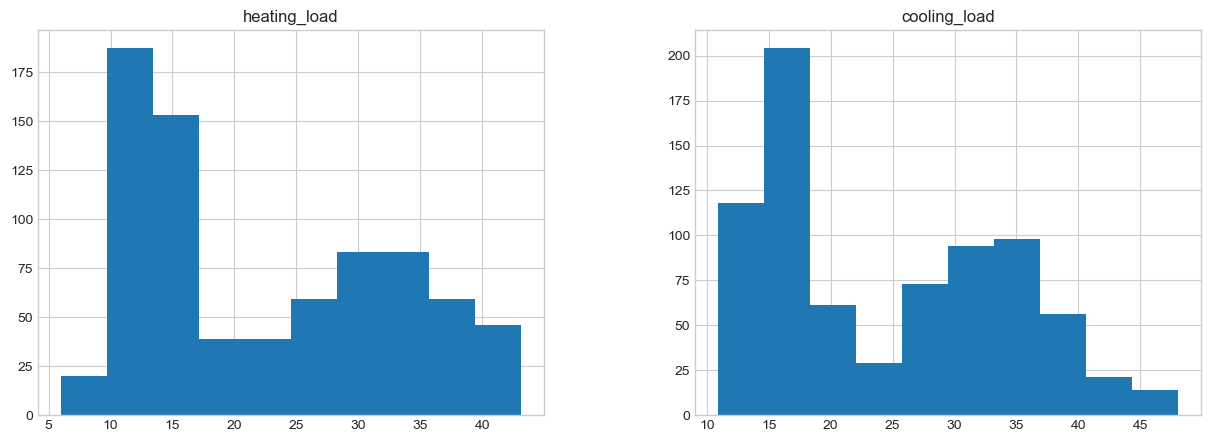

In [12]:
dfHeatCool = df[['heating_load','cooling_load']]
dfHeatCool.hist(figsize=(15,5))
plt.show()

<Axes: >

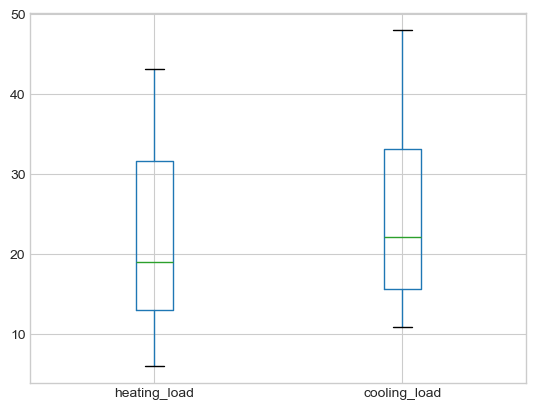

In [13]:
dfHeatCool.boxplot()

### Target Variable Observations

1. **Distribution shape:** Both targets are right skewed with non-normal distribution. Both targets have a similar shape initially, though only heating_load becomes left skewed after log transforming.
2. **Outliers:** No outliers
3. **Potential issues:** Due to distribution of targets, linear regression will likely not be a good fit. May need to use polynomial, ridge, or lasso regression to accurately predict targets.



## 4. Feature Distributions

In [14]:
#Log transform for observational purposes
dflogged = np.log(dfHeatCool[['heating_load','cooling_load']])

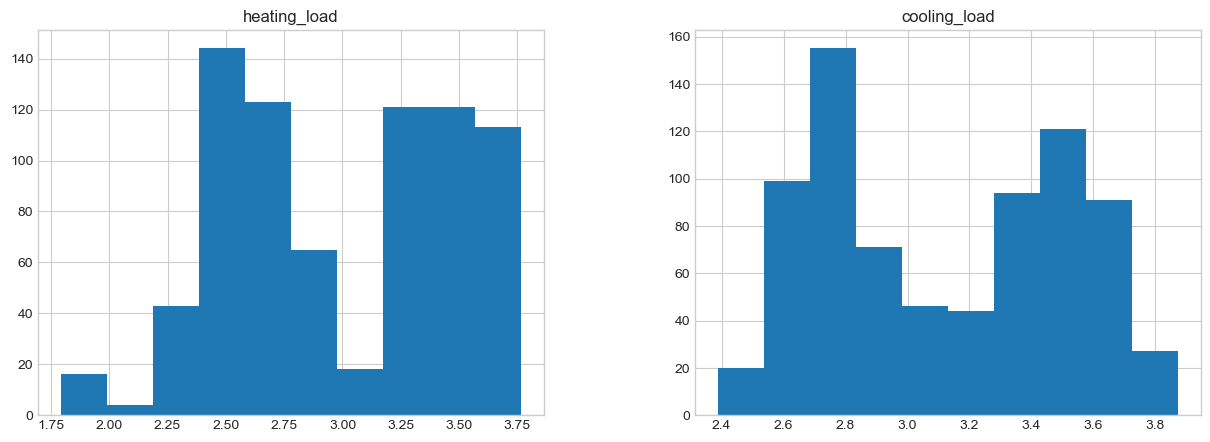

In [15]:
dflogged.hist(figsize=(15,5))
plt.show()

<Axes: >

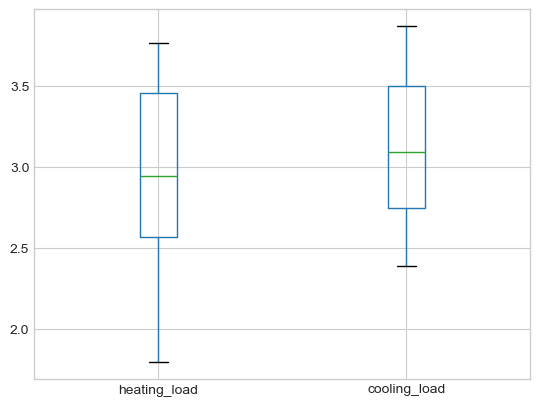

In [16]:
dflogged.boxplot()

### Feature Distribution Observations

Heating and Cooling loads are both left skewed with non-normal distribution. Log transforming the targets reduces the skew, but there is a dip in the middle 




## 5. Correlation Analysis

<Axes: >

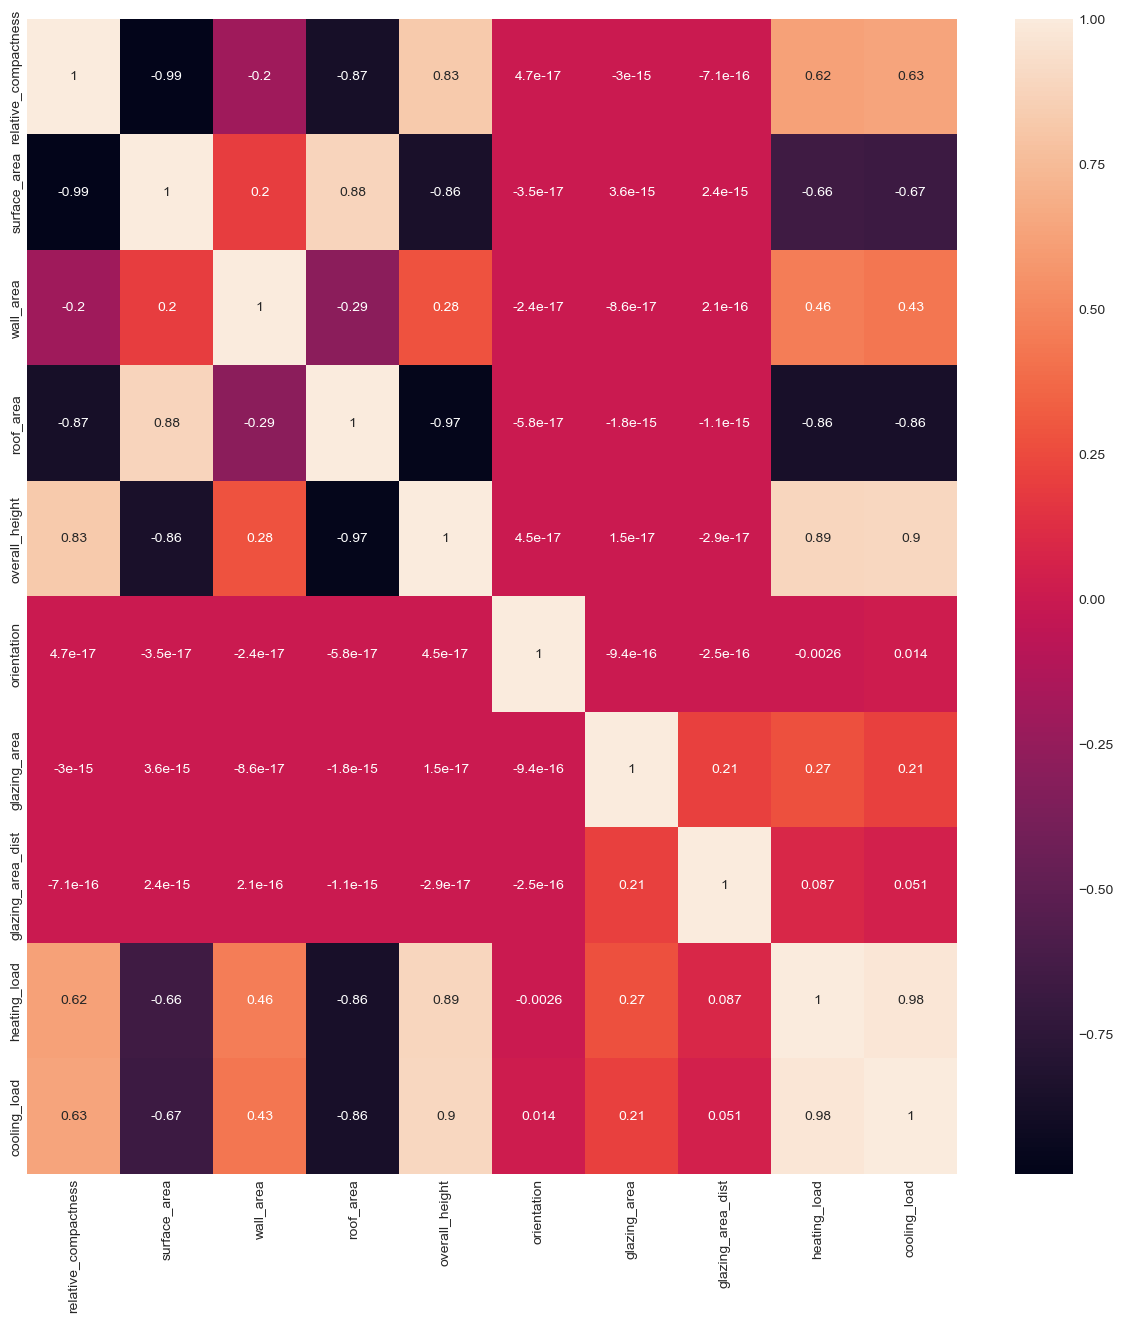

In [17]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True)

In [18]:
corr_matrix = df.corr()
corr_matrix['heating_load'].sort_values(ascending=False)

heating_load            1.000000
cooling_load            0.975862
overall_height          0.889431
relative_compactness    0.622272
wall_area               0.455671
glazing_area            0.269841
glazing_area_dist       0.087368
orientation            -0.002587
surface_area           -0.658120
roof_area              -0.861828
Name: heating_load, dtype: float64

In [19]:
corr_matrix = df.corr()
corr_matrix['cooling_load'].sort_values(ascending=False)

cooling_load            1.000000
heating_load            0.975862
overall_height          0.895785
relative_compactness    0.634339
wall_area               0.427117
glazing_area            0.207505
glazing_area_dist       0.050525
orientation             0.014290
surface_area           -0.672999
roof_area              -0.862547
Name: cooling_load, dtype: float64

**Note**  
will one-hot encode orientation to more accurately see correlation.

In [20]:
#2 (North), 3 (East), 4 (South), 5 (West)
df1h = pd.get_dummies(df, columns=['orientation'], prefix='orient')
df2h = pd.get_dummies(df1h, columns=['glazing_area_dist'], prefix='glaze_dist')

In [21]:
corr_matrix = df2h.corr()
corr_matrix['heating_load'].sort_values(ascending=False)

heating_load            1.000000
cooling_load            0.975862
overall_height          0.889431
relative_compactness    0.622272
wall_area               0.455671
glazing_area            0.269841
glaze_dist_1            0.034249
glaze_dist_2            0.029882
glaze_dist_4            0.027606
glaze_dist_3            0.017830
glaze_dist_5            0.017803
orient_3                0.004207
orient_2                0.000324
orient_5               -0.001823
orient_4               -0.002708
glaze_dist_0           -0.205377
surface_area           -0.658120
roof_area              -0.861828
Name: heating_load, dtype: float64

In [22]:
corr_matrix = df2h.corr()
corr_matrix['cooling_load'].sort_values(ascending=False)

cooling_load            1.000000
heating_load            0.975862
overall_height          0.895785
relative_compactness    0.634339
wall_area               0.427117
glazing_area            0.207505
glaze_dist_1            0.029901
orient_5                0.022220
glaze_dist_4            0.021595
glaze_dist_2            0.020672
glaze_dist_5            0.006429
glaze_dist_3            0.003622
orient_2                0.001018
orient_4               -0.006525
orient_3               -0.016713
glaze_dist_0           -0.132575
surface_area           -0.672999
roof_area              -0.862547
Name: cooling_load, dtype: float64

### Correlation Observations

1. **Strongest predictor:** Both targets have very similar relationships with the other variables. The strongest indicators seem to be overall_height and relative_compactness both having strong positive correlations with the targets, and roof_area and surface_area both having strong negative correlations with the targets.
2. **Other important features:** Though the orientation of glazing does have some minor impact on the heating and cooling loads, the amount of glaze overall plays a much more significant role. 
3. **Multicollinearity concerns:** All datapoints with glaze_dist_0 will also have a 0 value for glazing_area. Wall_area may have some collinearity with relative_compactness as a less compact structure would require larger walls.
4. **Additional info:** The targets are heavily collinear, likely because factors that would affect heating load would also affect cooling load similarly. Glazing_area was capped at 40% for the simulation, so any predictions past that amount would be inaccurate.


## 6. Key Findings Summary

1. Dataset: 768 rows, 10 columns, no missing values
2. Target: Both targets are right skewed
3. Strongest predictor: overall_height
4. The two targets, *cooling_load* and *heating_load,* are collinear and have very similar interactions with each respective variable.
5. *overall_height* and *relative_compactness* have a strong positive corellation with the targets, and *roof_area* and *surface_area* have strong negative correlation.

## EDA Checklist

Before moving to modeling, ensure you've completed:

- [ ] Loaded and examined the data
- [ ] Checked data types
- [ ] Identified and documented missing values
- [ ] Analyzed target variable distribution
- [ ] Examined feature distributions
- [ ] Created correlation analysis
- [ ] Documented key findings
- [ ] Identified potential data quality issues

In [23]:
#Code to export dataset so as to make next notebook easier
df.to_csv('../data/raw/ee.csv', index=False)
print("Export successful to /data/raw/ee.csv")

Export successful to /data/raw/ee.csv
